In [1]:
import os
import globals.path as pth
import globals.design as dn
import nitools as nt
from imaging_pipelines.vis import plot_surf
from matplotlib.colors import LinearSegmentedColormap, Normalize
import nibabel as nb
import numpy as np
from matplotlib.cm import ScalarMappable
import matplotlib.pyplot as plt

base directory found: /cifs/diedrichsen/data/Chord_exp/EFC_learningfMRI
Atlas directory found: atlases
figure directory found: figures/


/tmp/ipykernel_1243838/2311237365.py:8: RuntimeWarning: Mean of empty slice
  data_avg = np.nanmean(data, axis=1)[:, None]


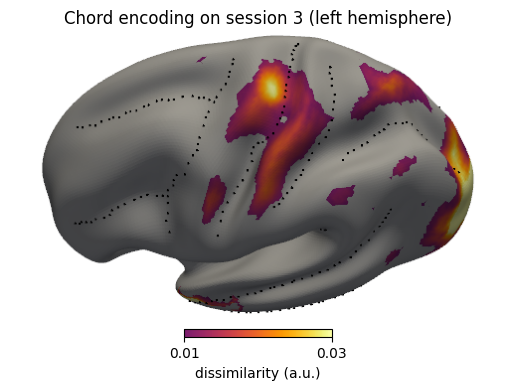

In [2]:
cmap = 'inferno'
thresh = 0.01
vmin, vmax = 0, .03
H = 'L'

gifti = nb.load(os.path.join(pth.baseDir, pth.surfDir, f'searchlight.encoding.session3.{H}.func.gii'))
data = nt.get_gifti_data_matrix(gifti)
data_avg = np.nanmean(data, axis=1)[:, None]
#data = np.full(data.shape, np.nan)

fig, ax = plt.subplots()
fig, ax = plot_surf(fig, ax, data_avg, H, col=0, vmin=vmin, vmax=vmax, thresh=thresh, cmap='inferno')

# ---- add colorbar ----
norm =Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(sm, ax=ax, fraction=0.02, pad=0.04, orientation='horizontal')
cbar.set_label('dissimilarity (a.u.)')
cbar.ax.set_xlim(thresh, vmax)
cbar.ax.set_xticks([thresh, vmax])
cbar.outline.set_edgecolor('k')

ax.set_title('Chord encoding on session 3 (left hemisphere)')

plt.show()

/tmp/ipykernel_1243838/1947671076.py:14: RuntimeWarning: Mean of empty slice
  data_avg = np.nanmean(data, axis=1)[:, None]
/tmp/ipykernel_1243838/1947671076.py:14: RuntimeWarning: Mean of empty slice
  data_avg = np.nanmean(data, axis=1)[:, None]
/tmp/ipykernel_1243838/1947671076.py:14: RuntimeWarning: Mean of empty slice
  data_avg = np.nanmean(data, axis=1)[:, None]


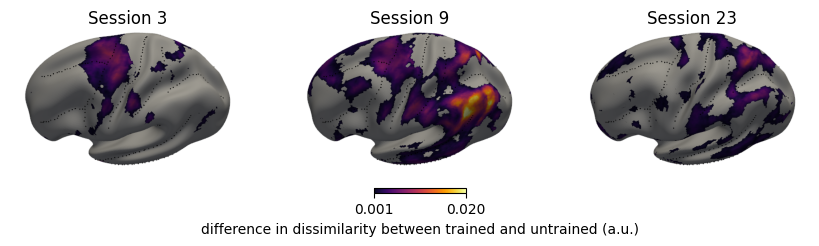

In [28]:
cmap = 'inferno'
thresh = 0.001
vmin, vmax = 0, .02
H = 'L'

fig, axs = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(8, 3),)

for s, sess in enumerate(dn.sessions):
    ax = axs[s]

    gifti_tr = nb.load(os.path.join(pth.baseDir, pth.surfDir, f'searchlight.encoding-trained.session{sess}.{H}.func.gii'))
    gifti_untr = nb.load(os.path.join(pth.baseDir, pth.surfDir, f'searchlight.encoding-untrained.session{sess}.{H}.func.gii'))
    data = nt.get_gifti_data_matrix(gifti_tr) - nt.get_gifti_data_matrix(gifti_untr)
    data_avg = np.nanmean(data, axis=1)[:, None]
    data_avg[data_avg < 0] = np.nan

    plot_surf(fig, ax, data_avg, H, col=0, vmin=vmin, vmax=vmax, thresh=thresh, cmap='inferno')

    ax.set_title(f'Session {sess}')

# ---- add colorbar ----
norm =Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(sm, ax=axs, fraction=0.02, pad=0.04, orientation='horizontal')
cbar.set_label('difference in dissimilarity between trained and untrained (a.u.)')
cbar.ax.set_xlim(thresh, vmax)
cbar.ax.set_xticks([thresh, vmax])
cbar.outline.set_edgecolor('k')

#fig.suptitle('Trained vs. untrained encoding')
plt.subplots_adjust(left=0, right=1, bottom=.2, top=.9, hspace=0)

plt.show()